# Phys 235 Schwinger VQS Main Skeleton

This notebook is the project entry point. It owns concrete parameter choices, fixture I/O, workflow ordering, validation display, and report-ready plots. Module `.py` files only define algorithms and callable interfaces.

## 1. Dependencies and Local Imports

In Google Colab, run the install command if dependencies are missing.

In [ ]:
# Uncomment in Colab if needed.
# %pip install -q pennylane scipy matplotlib

from pathlib import Path
import importlib
import json
import sys

import numpy as onp
import matplotlib.pyplot as plt

cwd = Path.cwd()
if (cwd / "module_4_vqe_quench.py").exists():
    CODE_DIR = cwd
elif (cwd / "code" / "module_4_vqe_quench.py").exists():
    CODE_DIR = cwd / "code"
else:
    CODE_DIR = Path("235_Final_Project") / "code"
PROJECT_ROOT = CODE_DIR.parent
TEST_DATA_ROOT = PROJECT_ROOT / "test_data"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import module_4_vqe_quench as module4_lib
module4_lib = importlib.reload(module4_lib)

from module_4_vqe_quench import (
    Module4Config,
    build_schwinger_hamiltonian,
    compute_observables,
    exact_time_evolution,
    hamiltonian_matrix,
    module4_acceptance_passed,
    run_module4_from_config,
    run_vqe,
)

from module_5_trotter import (
    Module5Config,
    module5_acceptance_passed,
    run_module5_from_config,
)

from module_6_mclachlan_vqs import (
    Module6Config,
    module6_acceptance_passed,
    run_module6_from_config,
)


## 2. Project Configuration

All concrete physics and optimizer choices live here. The source paper uses `q_final = 2` for the post-quench external field and `layer_count = 5` for the HVA depth.

In [ ]:
PHYSICS_CONFIG = {
    "N": 4,
    "ag": 1.0,
    "m_over_g": 1.0,
    "q_initial": 0.0,
    "q_final": 2.0,
    "g": 1.0,
    "layer_count": 5,
}

VQE_REPRO_CONFIG = {
    "n_restarts": 10,
    "seed": 1234,
    "learning_rate": 0.05,
    "max_steps": 200,
    "grad_tol": 1e-4,
    "stall_window": 100,
    "stall_tol": 1e-9,
    "use_lbfgs_polish": False,
}

VQE_FIXTURE_CONFIG = {
    **VQE_REPRO_CONFIG,
    "n_restarts": 5,
    "max_steps": 50,
}

# For a final reproduction run, use VQE_REPRO_CONFIG. For fast fixture regeneration, use VQE_FIXTURE_CONFIG.
ACTIVE_VQE_CONFIG = VQE_REPRO_CONFIG

LAYER_SWEEP_L_VALUES = [1, 2, 3, 4, 5]
LAYER_SWEEP_VQE_CONFIG = {
    **VQE_FIXTURE_CONFIG,
    "n_restarts": 20,
    "max_steps": 50,
}
RUN_LAYER_SWEEP = False
LAYER_SWEEP_INCLUDE_ZERO_INIT = False
USE_TEST_DATA_INPUT = True
REGENERATE_TEST_DATA = False

MODULE4_FIXTURE_DIR = TEST_DATA_ROOT / "module_4"
MODULE4_METADATA_PATH = MODULE4_FIXTURE_DIR / "metadata.json"
MODULE4_ARRAYS_PATH = MODULE4_FIXTURE_DIR / "arrays.npz"

TROTTER_CONFIG = {
    "total_time": 5.0,
    "n_steps": 100,
    "n_steps_scan": [10, 20, 40, 80, 160],
}

MODULE5_FIXTURE_DIR = TEST_DATA_ROOT / "module_5"
MODULE5_METADATA_PATH = MODULE5_FIXTURE_DIR / "metadata.json"
MODULE5_ARRAYS_PATH = MODULE5_FIXTURE_DIR / "arrays.npz"

VQS_CONFIG = {
    "total_time": 5.0,        # match TROTTER_CONFIG["total_time"] so curves overlay
    "n_steps": 400,           # F(T) ~ 0.996 at T=5; raise to 800 for F(T) ~ 0.999
    "n_steps_scan": [100, 200, 400, 800],
    "regularization": 1e-8,   # determinant-gated ridge for M
    "use_projector": True,    # projected (Q_psi) McLachlan EOM; False reproduces the bare failure
}

MODULE6_FIXTURE_DIR = TEST_DATA_ROOT / "module_6"
MODULE6_METADATA_PATH = MODULE6_FIXTURE_DIR / "metadata.json"
MODULE6_ARRAYS_PATH = MODULE6_FIXTURE_DIR / "arrays.npz"


## 3. Test Data API

Later modules should use this API when they need upstream statevectors, Hamiltonians, optimized VQE parameters, or smoke-test inputs without rerunning expensive VQE.

In [3]:
def make_module4_config(vqe_config):
    config = Module4Config(**PHYSICS_CONFIG, **vqe_config)
    config.validate()
    return config


def module4_summary(result):
    lines = [
        "Module 4 VQE + quench setup",
        f"N: {result.config.N}",
        f"ag: {result.config.ag}",
        f"m_over_g: {result.config.m_over_g}",
        f"q_initial: {result.config.q_initial}",
        f"q_final: {result.config.q_final}",
        f"layer_count: {result.config.layer_count}",
        f"best_energy: {result.vqe.best_energy:.12g}",
        f"exact_ground_energy: {result.vqe.exact_ground_energy:.12g}",
        f"r(E): {result.vqe.r_E:.12g}",
        f"ground_state_fidelity: {result.validation['ground_state_fidelity']:.12g}",
        f"post_quench_energy_q2: {result.quench.initial_energy_q2:.12g}",
        f"post_quench_variance_q2: {result.quench.initial_variance_q2:.12g}",
        f"acceptance_passed: {module4_acceptance_passed(result.validation)}",
    ]
    return "\n".join(lines)


def save_module4_test_data(result, metadata_path=MODULE4_METADATA_PATH, arrays_path=MODULE4_ARRAYS_PATH):
    metadata_path.parent.mkdir(parents=True, exist_ok=True)
    metadata = {
        "schema_version": 1,
        "module": "module_4",
        "description": "VQE q=0 ground-state and q=2 quench-ready fixture for smoke tests.",
        "source_paper": "Nagano, Bapat, Bauer, arXiv:2302.10933",
        "config": result.config.to_dict(),
        "validation": result.validation,
        "vqe": {
            "best_energy": result.vqe.best_energy,
            "adam_energy": result.vqe.adam_energy,
            "exact_ground_energy": result.vqe.exact_ground_energy,
            "exact_max_energy": result.vqe.exact_max_energy,
            "r_E": result.vqe.r_E,
            "polished": result.vqe.polished,
        },
        "quench": {
            "initial_energy_q0": result.quench.initial_energy_q0,
            "initial_energy_q2": result.quench.initial_energy_q2,
            "initial_variance_q2": result.quench.initial_variance_q2,
            "initial_observables_q2": result.quench.initial_observables_q2,
        },
        "arrays_file": arrays_path.name,
        "array_keys": [
            "theta_opt",
            "psi_0",
            "statevector",
            "exact_ground_state",
            "H_initial_matrix",
            "H_final_matrix",
        ],
    }
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    onp.savez_compressed(
        arrays_path,
        theta_opt=result.vqe.theta_opt,
        psi_0=result.quench.psi_0,
        statevector=result.vqe.statevector,
        exact_ground_state=result.vqe.exact_ground_state,
        H_initial_matrix=result.quench.H_initial_matrix,
        H_final_matrix=result.quench.H_final_matrix,
    )
    return metadata


def load_module_test_data(module_name, test_data_root=TEST_DATA_ROOT):
    module_dir = test_data_root / module_name
    with open(module_dir / "metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)
    arrays = onp.load(module_dir / metadata["arrays_file"], allow_pickle=False)
    return metadata, arrays


def load_module4_fixture():
    return load_module_test_data("module_4")


In [4]:
def make_module5_config():
    config = Module5Config(
        N=PHYSICS_CONFIG["N"],
        ag=PHYSICS_CONFIG["ag"],
        m_over_g=PHYSICS_CONFIG["m_over_g"],
        q_final=PHYSICS_CONFIG["q_final"],
        g=PHYSICS_CONFIG["g"],
        total_time=TROTTER_CONFIG["total_time"],
        n_steps=TROTTER_CONFIG["n_steps"],
        n_steps_scan=tuple(TROTTER_CONFIG["n_steps_scan"]),
    )
    config.validate()
    return config


def save_module5_test_data(result, metadata_path=MODULE5_METADATA_PATH, arrays_path=MODULE5_ARRAYS_PATH):
    metadata_path.parent.mkdir(parents=True, exist_ok=True)
    metadata = {
        "schema_version": 1,
        "module": "module_5",
        "description": "Second-order Suzuki-Trotter baseline for the q=2 post-quench dynamics.",
        "source_paper": "Nagano, Bapat, Bauer, arXiv:2302.10933",
        "config": result.config.to_dict(),
        "validation": result.validation,
        "convergence": {
            "n_steps_values": list(result.convergence.n_steps_values),
            "final_fidelity": result.convergence.final_fidelity.tolist(),
            "final_state_error": result.convergence.final_state_error.tolist(),
            "order_estimate": result.convergence.order_estimate,
        },
        "arrays_file": arrays_path.name,
        "array_keys": [
            "times",
            "trotter_electric_field",
            "trotter_chiral_condensate",
            "trotter_charge",
            "exact_electric_field",
            "exact_chiral_condensate",
            "exact_charge",
            "fidelity",
            "conv_n_steps",
            "conv_final_fidelity",
            "conv_final_state_error",
        ],
    }
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    onp.savez_compressed(
        arrays_path,
        times=result.trotter.times,
        trotter_electric_field=result.trotter.electric_field,
        trotter_chiral_condensate=result.trotter.chiral_condensate,
        trotter_charge=result.trotter.charge,
        exact_electric_field=result.exact.electric_field,
        exact_chiral_condensate=result.exact.chiral_condensate,
        exact_charge=result.exact.charge,
        fidelity=result.fidelity,
        conv_n_steps=onp.asarray(result.convergence.n_steps_values, dtype=int),
        conv_final_fidelity=result.convergence.final_fidelity,
        conv_final_state_error=result.convergence.final_state_error,
    )
    return metadata


def load_module5_fixture():
    metadata, arrays = load_module_test_data("module_5")
    return metadata, arrays


In [ ]:
def make_module6_config():
    config = Module6Config(
        N=PHYSICS_CONFIG["N"],
        ag=PHYSICS_CONFIG["ag"],
        m_over_g=PHYSICS_CONFIG["m_over_g"],
        q_final=PHYSICS_CONFIG["q_final"],
        g=PHYSICS_CONFIG["g"],
        layer_count=PHYSICS_CONFIG["layer_count"],
        total_time=VQS_CONFIG["total_time"],
        n_steps=VQS_CONFIG["n_steps"],
        n_steps_scan=tuple(VQS_CONFIG["n_steps_scan"]),
        regularization=VQS_CONFIG["regularization"],
        use_projector=VQS_CONFIG["use_projector"],
    )
    config.validate()
    return config


def save_module6_test_data(result, metadata_path=MODULE6_METADATA_PATH, arrays_path=MODULE6_ARRAYS_PATH):
    metadata_path.parent.mkdir(parents=True, exist_ok=True)
    metadata = {
        "schema_version": 1,
        "module": "module_6",
        "description": "Projected McLachlan VQS baseline for the q=2 post-quench dynamics.",
        "source_paper": "Nagano, Bapat, Bauer, arXiv:2302.10933",
        "config": result.config.to_dict(),
        "validation": result.validation,
        "convergence": {
            "n_steps_values": list(result.convergence.n_steps_values),
            "final_fidelity": result.convergence.final_fidelity.tolist(),
            "final_infidelity": result.convergence.final_infidelity.tolist(),
            "order_estimate": result.convergence.order_estimate,
        },
        "arrays_file": arrays_path.name,
        "array_keys": [
            "times",
            "vqs_electric_field",
            "vqs_chiral_condensate",
            "vqs_charge",
            "exact_electric_field",
            "exact_chiral_condensate",
            "exact_charge",
            "fidelity",
            "residual",
            "params",
            "conv_n_steps",
            "conv_final_fidelity",
            "conv_final_infidelity",
        ],
    }
    with open(metadata_path, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)
    onp.savez_compressed(
        arrays_path,
        times=result.trajectory.times,
        vqs_electric_field=result.vqs.electric_field,
        vqs_chiral_condensate=result.vqs.chiral_condensate,
        vqs_charge=result.vqs.charge,
        exact_electric_field=result.exact.electric_field,
        exact_chiral_condensate=result.exact.chiral_condensate,
        exact_charge=result.exact.charge,
        fidelity=result.fidelity,
        residual=result.trajectory.residual,
        params=result.trajectory.params,
        conv_n_steps=onp.asarray(result.convergence.n_steps_values, dtype=int),
        conv_final_fidelity=result.convergence.final_fidelity,
        conv_final_infidelity=result.convergence.final_infidelity,
    )
    return metadata


def load_module6_fixture():
    metadata, arrays = load_module_test_data("module_6")
    return metadata, arrays


## 4. Module 4: VQE Ground State and Quench Setup

Use fixture input for smoke tests, or regenerate the data live by setting `USE_TEST_DATA_INPUT = False` or `REGENERATE_TEST_DATA = True`.

In [5]:
if USE_TEST_DATA_INPUT and MODULE4_METADATA_PATH.exists() and not REGENERATE_TEST_DATA:
    module4_metadata, module4_arrays = load_module4_fixture()
    module4_config = Module4Config(**module4_metadata["config"])
    print("Loaded Module 4 fixture from", MODULE4_METADATA_PATH)
    print("r(E):", module4_metadata["validation"]["r_E"])
else:
    module4_config = make_module4_config(ACTIVE_VQE_CONFIG)
    module4_result = run_module4_from_config(module4_config)
    print(module4_summary(module4_result))
    module4_metadata = save_module4_test_data(module4_result)
    module4_arrays = onp.load(MODULE4_ARRAYS_PATH, allow_pickle=False)
    print("Saved Module 4 fixture to", MODULE4_FIXTURE_DIR)


Module 4 VQE + quench setup
N: 4
ag: 1.0
m_over_g: 1.0
q_initial: 0.0
q_final: 2.0
layer_count: 5
best_energy: -2.27655890452
exact_ground_energy: -2.27656458643
r(E): 0.999999105079
ground_state_fidelity: 0.999998468179
post_quench_energy_q2: 3.79555224495
post_quench_variance_q2: 0.383960922862
acceptance_passed: True
Saved Module 4 fixture to d:\UCLA_HW\Spring_2026\Phys_235\235_Final_Project\test_data\module_4


### 4.1 VQE Layer-Depth Restart Distribution

This sweep checks how the optimized VQE accuracy depends on HVA depth `L`. For each `L`, every random restart is treated as one initial-parameter trial, then its final energy is converted to the paper metric `r(E)`. The deterministic zero initialization is excluded by default. The plot reports the mean and uses the 25th-75th percentile range as the error bar.

In [6]:
def run_layer_sweep_distribution(l_values, physics_config, vqe_config, include_zero_init=False):
    H_initial = build_schwinger_hamiltonian(
        N=physics_config["N"],
        ag=physics_config["ag"],
        m_over_g=physics_config["m_over_g"],
        external_field=physics_config["q_initial"],
        g=physics_config["g"],
    )

    rows = []
    for layer_count in l_values:
        result = run_vqe(
            H_initial=H_initial,
            layer_count=layer_count,
            n_restarts=vqe_config["n_restarts"],
            seed=vqe_config["seed"],
            learning_rate=vqe_config["learning_rate"],
            max_steps=vqe_config["max_steps"],
            grad_tol=vqe_config["grad_tol"],
            stall_window=vqe_config["stall_window"],
            stall_tol=vqe_config["stall_tol"],
            use_lbfgs_polish=False,
        )
        denom = result.exact_max_energy - result.exact_ground_energy
        included_records = [
            record
            for record in result.restart_history
            if isinstance(record["restart"], int)
            and (include_zero_init or record["restart"] != 0)
        ]
        restart_r_E = onp.array(
            [(result.exact_max_energy - record["energy"]) / denom for record in included_records],
            dtype=float,
        )
        if restart_r_E.size == 0:
            raise ValueError("Layer sweep has no restart samples. Increase n_restarts or include zero initialization.")
        rows.append(
            {
                "L": layer_count,
                "r_E_values": restart_r_E,
                "r_E_mean": float(onp.mean(restart_r_E)),
                "r_E_p25": float(onp.percentile(restart_r_E, 25)),
                "r_E_p75": float(onp.percentile(restart_r_E, 75)),
                "r_E_min": float(onp.min(restart_r_E)),
                "r_E_max": float(onp.max(restart_r_E)),
                "r_E_std": float(onp.std(restart_r_E, ddof=1)) if restart_r_E.size > 1 else 0.0,
                "best_r_E": float(onp.max(restart_r_E)),
                "best_energy": float(min(record["energy"] for record in included_records)),
                "sample_count": int(restart_r_E.size),
            }
        )
        print(
            f"L={layer_count}: samples={rows[-1]['sample_count']}, "
            f"mean r(E)={rows[-1]['r_E_mean']:.10f}, "
            f"p25={rows[-1]['r_E_p25']:.10f}, p75={rows[-1]['r_E_p75']:.10f}, "
            f"best={rows[-1]['best_r_E']:.10f}"
        )
    return rows


if RUN_LAYER_SWEEP:
    layer_sweep_rows = run_layer_sweep_distribution(
        LAYER_SWEEP_L_VALUES,
        PHYSICS_CONFIG,
        LAYER_SWEEP_VQE_CONFIG,
        include_zero_init=LAYER_SWEEP_INCLUDE_ZERO_INIT,
    )
else:
    layer_sweep_rows = []
    print("Layer sweep skipped. Set RUN_LAYER_SWEEP = True to generate the r(E) distribution plot.")


Layer sweep skipped. Set RUN_LAYER_SWEEP = True to generate the r(E) distribution plot.


In [7]:
if layer_sweep_rows:
    layer_values = onp.array([row["L"] for row in layer_sweep_rows], dtype=int)
    r_E_mean = onp.array([row["r_E_mean"] for row in layer_sweep_rows], dtype=float)
    r_E_p25 = onp.array([row["r_E_p25"] for row in layer_sweep_rows], dtype=float)
    r_E_p75 = onp.array([row["r_E_p75"] for row in layer_sweep_rows], dtype=float)
    yerr = onp.vstack([r_E_mean - r_E_p25, r_E_p75 - r_E_mean])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(
        layer_values,
        r_E_mean,
        yerr=yerr,
        fmt="o",
        color="tab:blue",
        ecolor="tab:blue",
        elinewidth=1.5,
        capsize=4,
        markersize=6,
    )
    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.5)
    ax.set_xticks(layer_values)
    ax.set_xlabel(r"$L$")
    ax.set_ylabel(r"$r(E)$")
    ax.set_title(
        f"N={PHYSICS_CONFIG['N']}, "
        f"ag={PHYSICS_CONFIG['ag']:.1f}, "
        f"m/g={PHYSICS_CONFIG['m_over_g']:.1f}, "
        f"q={PHYSICS_CONFIG['q_initial']:g}",
        fontweight="bold",
    )

    y_min = float(onp.min(r_E_p25))
    y_max = float(onp.max(r_E_p75))
    pad = max(1e-5, 0.08 * max(y_max - y_min, 1e-6))
    ax.set_ylim(y_min - pad, max(1.00002, y_max + pad))
    fig.tight_layout()
    plt.show()
else:
    print("No layer_sweep_rows available for plotting.")


No layer_sweep_rows available for plotting.


## 5. Validation Gate

Later modules should not run unless the live result or loaded fixture satisfies the Module 4 acceptance checks.

In [8]:
if "module4_result" in globals():
    module4_ready = module4_acceptance_passed(module4_result.validation)
    validation_source = module4_result.validation
else:
    module4_ready = bool(float(module4_metadata["validation"]["r_E"]) > 0.99)
    validation_source = module4_metadata["validation"]

print("Module 4 ready for dynamics:", module4_ready)
for key, value in validation_source.items():
    print(f"{key}: {value}")

assert module4_ready, "Module 4 validation failed; do not proceed to Trotter/VQS yet."


Module 4 ready for dynamics: True
r_E: 0.9999991050789333
vqe_energy: -2.276558904524777
exact_ground_energy: -2.2765645864303865
ground_state_fidelity: 0.9999984681788505
q2_energy_variance: 0.3839609228619558
commutator_norm_q0: 0.0
commutator_norm_q2: 0.0


## 6. Downstream Input API

This payload is the stable preinput for later modules: optimized parameters, the quench-ready state, and exact Hamiltonian matrices.

In [9]:
module4_downstream_input = {
    "config": module4_metadata["config"],
    "theta_opt": module4_arrays["theta_opt"],
    "psi_0": module4_arrays["psi_0"],
    "H_initial_matrix": module4_arrays["H_initial_matrix"],
    "H_final_matrix": module4_arrays["H_final_matrix"],
    "validation": module4_metadata["validation"],
}

for key, value in module4_downstream_input.items():
    if hasattr(value, "shape"):
        print(key, value.shape)
    else:
        print(key, type(value))


config <class 'dict'>
theta_opt (50,)
psi_0 (16,)
H_initial_matrix (16, 16)
H_final_matrix (16, 16)
validation <class 'dict'>


## 7. Exact Reference Smoke Output

This is a small exact-evolution reference generated from the Module 4 downstream input. It is for interface validation; final plots should be produced after Trotter and VQS modules exist.

In [10]:
times = onp.linspace(0.0, 1.0, 11)
states = exact_time_evolution(
    module4_downstream_input["H_final_matrix"],
    module4_downstream_input["psi_0"],
    times,
)

reference = {"times": times, "electric_field": [], "chiral_condensate": [], "charge": []}
for state in states:
    obs = compute_observables(
        state,
        N=module4_config.N,
        ag=module4_config.ag,
        external_field=module4_config.q_final,
        g=module4_config.g,
    )
    reference["electric_field"].append(obs["electric_field"])
    reference["chiral_condensate"].append(obs["chiral_condensate"])
    reference["charge"].append(obs["charge"])

for key in ["electric_field", "chiral_condensate", "charge"]:
    reference[key] = onp.asarray(reference[key], dtype=float)
    print(key, reference[key].shape)


electric_field (11,)
chiral_condensate (11,)
charge (11,)


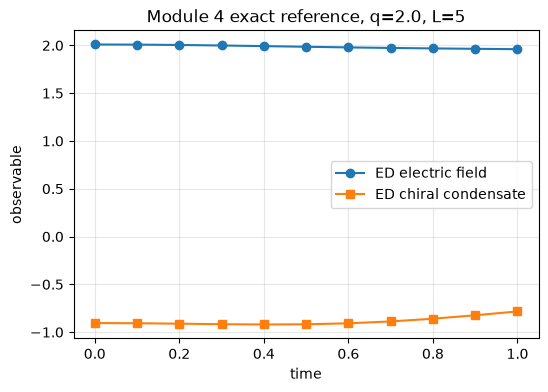

In [11]:
plt.figure(figsize=(6, 4))
plt.plot(reference["times"], reference["electric_field"], marker="o", label="ED electric field")
plt.plot(reference["times"], reference["chiral_condensate"], marker="s", label="ED chiral condensate")
plt.xlabel("time")
plt.ylabel("observable")
plt.title(f"Module 4 exact reference, q={module4_config.q_final}, L={module4_config.layer_count}")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 8. Module 5: Suzuki-Trotter Quench Baseline

Evolve the Module 4 quench state `psi_0` under `H(q=2)` with a second-order
Suzuki-Trotter (Strang) product formula, and compare observables and fidelity
against the exact `expm(-iHt)` reference. Uses fixture input for smoke tests, or
regenerates live with the same `USE_TEST_DATA_INPUT` / `REGENERATE_TEST_DATA`
switches as Module 4.

In [12]:
module5_psi_0 = onp.asarray(module4_downstream_input["psi_0"], dtype=complex)

if USE_TEST_DATA_INPUT and MODULE5_METADATA_PATH.exists() and not REGENERATE_TEST_DATA:
    module5_metadata, module5_arrays = load_module5_fixture()
    print("Loaded Module 5 fixture from", MODULE5_METADATA_PATH)
    print("F(T):", module5_metadata["validation"]["final_fidelity"])
else:
    module5_config = make_module5_config()
    module5_result = run_module5_from_config(module5_config, module5_psi_0)
    print("Module 5 Trotter baseline")
    print("  split_sum_error:", module5_result.validation["split_sum_error"])
    print("  final_fidelity F(T):", module5_result.validation["final_fidelity"])
    print("  min_fidelity:", module5_result.validation["min_fidelity"])
    print("  trotter_order_estimate:", module5_result.validation["trotter_order_estimate"])
    module5_metadata = save_module5_test_data(module5_result)
    module5_arrays = onp.load(MODULE5_ARRAYS_PATH, allow_pickle=False)
    print("Saved Module 5 fixture to", MODULE5_FIXTURE_DIR)


Module 5 Trotter baseline
  split_sum_error: 0.0
  final_fidelity F(T): 0.999999811801046
  min_fidelity: 0.9999993056968198
  trotter_order_estimate: 2.0336311610685325
Saved Module 5 fixture to d:\UCLA_HW\Spring_2026\Phys_235\235_Final_Project\test_data\module_5


In [13]:
if "module5_result" in globals():
    module5_ready = module5_acceptance_passed(module5_result.validation)
    validation_source = module5_result.validation
else:
    module5_ready = bool(float(module5_metadata["validation"]["final_fidelity"]) > 0.99)
    validation_source = module5_metadata["validation"]

print("Module 5 ready for VQS comparison:", module5_ready)
for key, value in validation_source.items():
    print(f"{key}: {value}")

assert module5_ready, "Module 5 Trotter baseline failed acceptance; do not proceed to VQS comparison."


Module 5 ready for VQS comparison: True
split_sum_error: 0.0
final_fidelity: 0.999999811801046
min_fidelity: 0.9999993056968198
fidelity_monotonic: True
trotter_order_estimate: 2.0336311610685325


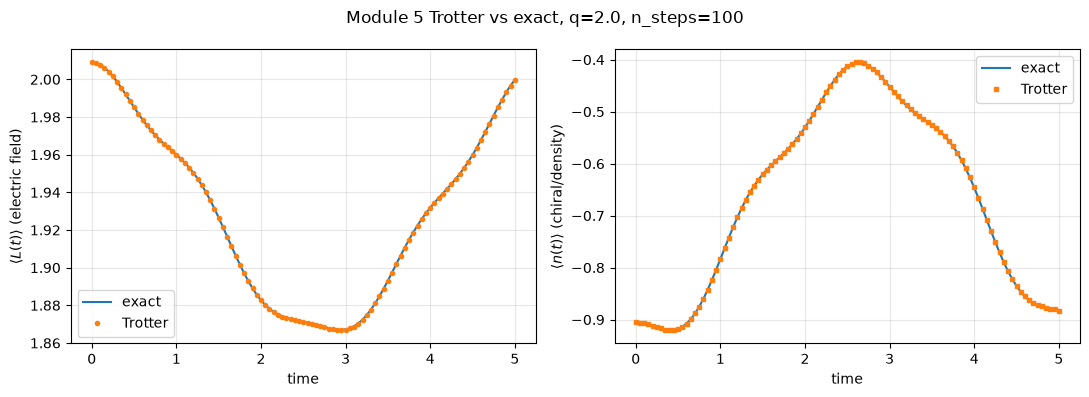

In [14]:
m5_times = module5_arrays["times"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(m5_times, module5_arrays["exact_electric_field"], "-", label="exact")
axes[0].plot(m5_times, module5_arrays["trotter_electric_field"], "o", ms=3, label="Trotter")
axes[0].set_xlabel("time")
axes[0].set_ylabel(r"$\langle L(t)\rangle$ (electric field)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(m5_times, module5_arrays["exact_chiral_condensate"], "-", label="exact")
axes[1].plot(m5_times, module5_arrays["trotter_chiral_condensate"], "s", ms=3, label="Trotter")
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"$\langle n(t)\rangle$ (chiral/density)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

n_steps_used = module5_metadata["config"]["n_steps"]
fig.suptitle(f"Module 5 Trotter vs exact, q={module5_metadata['config']['q_final']}, n_steps={n_steps_used}")
fig.tight_layout()
plt.show()


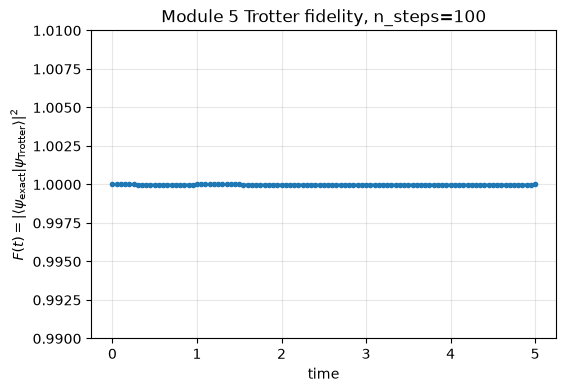

In [15]:
plt.figure(figsize=(6, 4))
plt.plot(m5_times, module5_arrays["fidelity"], "-o", ms=3)
plt.xlabel("time")
plt.ylabel(r"$F(t)=|\langle\psi_{\mathrm{exact}}|\psi_{\mathrm{Trotter}}\rangle|^2$")
plt.title(f"Module 5 Trotter fidelity, n_steps={module5_metadata['config']['n_steps']}")
plt.grid(True, alpha=0.3)
plt.ticklabel_format(axis="y", style="plain", useOffset=False)
plt.ylim(0.99, 1.01)
plt.show()


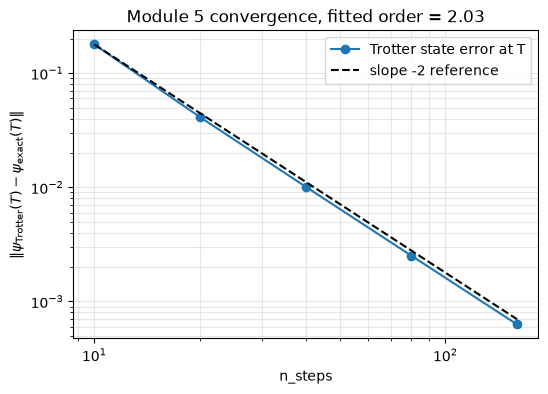

In [16]:
conv_n = module5_arrays["conv_n_steps"]
conv_err = module5_arrays["conv_final_state_error"]
order = module5_metadata["convergence"]["order_estimate"]

plt.figure(figsize=(6, 4))
plt.loglog(conv_n, conv_err, "o-", label="Trotter state error at T")
plt.loglog(conv_n, conv_err[0] * (conv_n / conv_n[0]) ** -2.0, "k--", label="slope -2 reference")
plt.xlabel("n_steps")
plt.ylabel(r"$\|\psi_{\mathrm{Trotter}}(T)-\psi_{\mathrm{exact}}(T)\|$")
plt.title(f"Module 5 convergence, fitted order = {order:.2f}")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


## 9. Module 6: McLachlan Variational Quantum Simulation

Evolve the Module 4 HVA parameters `theta(t)` (from `theta_opt`) under `H(q=2)` by
solving the projected McLachlan equation of motion `M theta_dot = V` with a
regularized Euler step, at constant circuit depth. Compare observables and
fidelity against the exact `expm(-iHt)` reference and the Module 5 Trotter
baseline (paper Fig. 6). Uses the same `USE_TEST_DATA_INPUT` / `REGENERATE_TEST_DATA`
switches as Modules 4 and 5.

In [ ]:
module6_theta0 = onp.asarray(module4_downstream_input["theta_opt"], dtype=float)

if USE_TEST_DATA_INPUT and MODULE6_METADATA_PATH.exists() and not REGENERATE_TEST_DATA:
    module6_metadata, module6_arrays = load_module6_fixture()
    print("Loaded Module 6 fixture from", MODULE6_METADATA_PATH)
    print("F(T):", module6_metadata["validation"]["final_fidelity"])
else:
    module6_config = make_module6_config()
    module6_result = run_module6_from_config(module6_config, module6_theta0)
    print("Module 6 McLachlan VQS baseline")
    print("  final_fidelity F(T):", module6_result.validation["final_fidelity"])
    print("  min_fidelity:", module6_result.validation["min_fidelity"])
    print("  charge_drift:", module6_result.validation["charge_drift"])
    print("  max_residual:", module6_result.validation["max_residual"])
    print("  infidelity_order_estimate:", module6_result.validation["infidelity_order_estimate"])
    module6_metadata = save_module6_test_data(module6_result)
    module6_arrays = onp.load(MODULE6_ARRAYS_PATH, allow_pickle=False)
    print("Saved Module 6 fixture to", MODULE6_FIXTURE_DIR)


In [ ]:
if "module6_result" in globals():
    module6_ready = module6_acceptance_passed(module6_result.validation)
    validation_source = module6_result.validation
else:
    module6_ready = bool(float(module6_metadata["validation"]["final_fidelity"]) > 0.99)
    validation_source = module6_metadata["validation"]

print("Module 6 VQS reproduction acceptable:", module6_ready)
for key, value in validation_source.items():
    print(f"{key}: {value}")

assert module6_ready, "Module 6 VQS baseline failed acceptance."


In [ ]:
m6_times = module6_arrays["times"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(m6_times, module6_arrays["exact_electric_field"], "-", label="exact")
if "module5_arrays" in globals():
    axes[0].plot(module5_arrays["times"], module5_arrays["trotter_electric_field"], "o", ms=3, label="Trotter")
axes[0].plot(m6_times, module6_arrays["vqs_electric_field"], "x", ms=4, label="VQS")
axes[0].set_xlabel("time")
axes[0].set_ylabel(r"$\langle L(t)\rangle$ (electric field)")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(m6_times, module6_arrays["exact_chiral_condensate"], "-", label="exact")
if "module5_arrays" in globals():
    axes[1].plot(module5_arrays["times"], module5_arrays["trotter_chiral_condensate"], "s", ms=3, label="Trotter")
axes[1].plot(m6_times, module6_arrays["vqs_chiral_condensate"], "x", ms=4, label="VQS")
axes[1].set_xlabel("time")
axes[1].set_ylabel(r"$\langle n(t)\rangle$ (chiral/density)")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.suptitle(f"Module 6 VQS vs Trotter vs exact, q={module6_metadata['config']['q_final']}, "
             f"L={module6_metadata['config']['layer_count']}, n_steps={module6_metadata['config']['n_steps']}")
fig.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(m6_times, module6_arrays["fidelity"], "-x", ms=4, label="VQS")
if "module5_arrays" in globals():
    plt.plot(module5_arrays["times"], module5_arrays["fidelity"], "-o", ms=3, label="Trotter")
plt.xlabel("time")
plt.ylabel(r"$F(t)=|\langle\psi_{\mathrm{exact}}|\psi\rangle|^2$")
plt.title(f"Fidelity vs exact, VQS n_steps={module6_metadata['config']['n_steps']}")
plt.grid(True, alpha=0.3)
plt.ylim(top=1.001)
plt.legend()
plt.show()


In [ ]:
conv_n = module6_arrays["conv_n_steps"]
conv_infid = module6_arrays["conv_final_infidelity"]
order = module6_metadata["convergence"]["order_estimate"]

plt.figure(figsize=(6, 4))
plt.loglog(conv_n, conv_infid, "o-", label="VQS final infidelity $1-F(T)$")
plt.loglog(conv_n, conv_infid[0] * (conv_n / conv_n[0]) ** -2.0, "k--", label="slope -2 reference")
plt.xlabel("n_steps")
plt.ylabel(r"$1 - F(T)$")
plt.title(f"Module 6 Euler convergence, fitted infidelity order = {order:.2f}")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.show()


In [ ]:
if "module6_result" in globals():
    from module_6_mclachlan_vqs import run_vqs_evolution

    H_final_q2 = onp.asarray(module4_downstream_input["H_final_matrix"], dtype=complex)
    bare_traj = run_vqs_evolution(
        module6_theta0, H_final_q2,
        PHYSICS_CONFIG["layer_count"], PHYSICS_CONFIG["N"],
        VQS_CONFIG["total_time"], VQS_CONFIG["n_steps"],
        VQS_CONFIG["regularization"], projected=False,
    )
    exact_states = exact_time_evolution(H_final_q2, module6_result.trajectory.states[0], module6_result.trajectory.times)
    bare_fidelity = onp.array([
        module4_lib.state_fidelity(exact_states[k], bare_traj.states[k])
        for k in range(len(module6_result.trajectory.times))
    ])

    plt.figure(figsize=(6, 4))
    plt.plot(m6_times, module6_arrays["fidelity"], "-x", ms=4, label="projected (Q_psi)")
    plt.plot(m6_times, bare_fidelity, "-o", ms=3, label="bare A,C")
    plt.xlabel("time")
    plt.ylabel(r"$F(t)$")
    plt.title("Why the phase projector is needed (vqs_notes.tex)")
    plt.grid(True, alpha=0.3)
    plt.ylim(0.0, 1.02)
    plt.legend()
    plt.show()
else:
    print("Bare-vs-projected demo skipped (fixture-load session; run with REGENERATE_TEST_DATA=True).")
